# 증강과오류분석

학습·평가에 맞는 변환을 구현하고, 직접 학습한 모델의 오류를 분석합니다.

함수명·입출력·API 예시는 제공합니다. **작성 구간의 처리 로직을 직접 구성하세요.**
검증 셀은 수정하지 않습니다. 파일 안에서는 위에서부터 실행합니다.


In [5]:
from pathlib import Path
import os, sys, json, time

# root 자동 탐색 코드
# ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p/'signlab.py').exists()), None)
# if ROOT is None: raise RuntimeError('오전_최종본 폴더에서 실행하세요.')

# 기존 자동 탐색 코드를 지우고, 확인된 절대 경로를 직접 주입합니다.  - 00 오전 실습 준비에서 위치 찾아서 수정
ROOT = Path(r"C:\Users\User\.ngv_day4_2026\am\9de5e80f5a44")

sys.path.insert(0,str(ROOT))
os.environ['MPLCONFIGDIR']=str(ROOT/'.runtime/matplotlib')
os.environ['YOLO_CONFIG_DIR']=str(ROOT/'.runtime/yolo')
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance, ImageOps, ImageDraw
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
torch.set_num_threads(4)
plt.rcParams['font.family']='Malgun Gothic'
plt.rcParams['axes.unicode_minus']=False
import signlab as lab
data=lab.load_data()
NAMES=lab.NAMES_KO


## 입력 변환 재사용 · 제공 코드
01에서 구현한 입력 변환은 완성 코드로 제공합니다. 다시 작성하지 않습니다.


In [6]:
def make_batch(images,color_order='RGB'):
    tensors=[]
    for pixels in images:
        rgb=pixels if color_order=='RGB' else pixels[:,:,::-1]
        tensor=torch.from_numpy(np.array(rgb,copy=True,order="C")).float().permute(2,0,1)/255
        tensors.append((tensor-.5)/.5)
    return torch.stack(tensors)


## ✏️ A04 · 학습용 증강과 평가용 입력 분리

입력: 사진 한 장, 정답 번호, 밝기 강도(0~1), 학습 여부, 난수 생성기.
학습일 때만 1±강도 범위에서 밝기를 무작위 변경합니다. 평가에서는 원본을 유지합니다.
반환: `[3,H,W]` 텐서와 정수 정답. 사진 원본과 정답 의미를 유지하세요.

### 사용할 수 있는 API
`Image.fromarray`, `ImageEnhance.Brightness(image).enhance(factor)`, `np.asarray`, 앞 셀의 `make_batch`.
`rng.uniform(a,b)`는 a~b 사이 값 하나를 반환합니다. 검증은 전달된 rng를 사용합니다.


In [7]:
# ===== 실습 A04 시작 =====

def augment_sample(pixels,label,strength,training,rng):
    image= Image.fromarray(pixels)
    if training:
        factor=rng.uniform(1-strength,1+strength)
        image=ImageEnhance.Brightness(image).enhance(factor)
    return make_batch([np.asarray(image)])[0], int(label)
    # raise NotImplementedError('A04: 학습/평가 변환 구성')

# ===== 실습 A04 끝 =====


**A04 검증** · 아래 셀이 통과한 뒤 실제 데이터에 적용합니다.


In [8]:
picture=data['train'].images[0].copy();original=picture.copy()
for training,strength in [(False,.8),(True,0.)]:
    x,y=augment_sample(picture,3,strength,training,np.random.default_rng(10))
    assert torch.allclose(x,make_batch([picture])[0]) and y==3,'A04: 평가/강도0에서는 원본과 정답을 유지합니다.'
rng=np.random.default_rng(12);factor=rng.uniform(.4,1.6)
x,y=augment_sample(picture,2,.6,True,np.random.default_rng(12))
expected=make_batch([np.asarray(ImageEnhance.Brightness(Image.fromarray(picture)).enhance(factor))])[0]
assert torch.allclose(x,expected) and isinstance(y,int) and y==2,'A04: 밝기 범위·정규화·정답을 확인하세요.'
assert np.array_equal(picture,original),'A04: 원본을 변경하지 마세요.'
print('A04 통과: 학습/평가 분리·범위·정답·원본 보존')


A04 통과: 학습/평가 분리·범위·정답·원본 보존


## 작성한 변환으로 실제 학습 · 제공 코드
같은 모델·데이터 순서·10 epoch에서 증강 유무만 비교합니다.
`RETRAIN=False`는 제공 모델 확인용이며 작성한 변환으로 학습한 결과가 아닙니다.


In [9]:
def train_step(model,x,y,optimizer,criterion):
    optimizer.zero_grad()
    logits=model(x)
    loss=criterion(logits,y)
    loss.backward()
    optimizer.step()
    return float(loss.detach())
@torch.inference_mode()
def evaluate(model,dataset,batch_size=64):
    model.eval()
    truth,pred,scores = [],[],[]
    total_loss = 0.0
    for x,y in DataLoader(dataset,batch_size=batch_size,shuffle=False,num_workers=0):
        logits = model(x)
        total_loss += nn.functional.cross_entropy(logits,y,reduction='sum').item()
        probabilities = logits.softmax(1)
        confidence,labels = probabilities.max(1)
        truth.extend(y.tolist());pred.extend(labels.tolist());scores.extend(confidence.tolist())
    truth,pred = np.asarray(truth),np.asarray(pred)
    matrix = np.zeros((8,8),dtype=int)
    np.add.at(matrix,(truth,pred),1)
    return {'accuracy':float((truth==pred).mean()),'loss':total_loss/len(dataset),
            'truth':truth,'prediction':pred,'scores':np.asarray(scores),'confusion':matrix}
class AugDataset(Dataset):
    def __init__(self,source,strength):self.source=source;self.strength=strength;self.rng=np.random.default_rng(42)
    def __len__(self):return len(self.source)
    def __getitem__(self,i):return augment_sample(self.source.images[i],self.source.labels[i],self.strength,True,self.rng)
def train_aug(strength):
    lab.seed_all(42);model=lab.SmallCNN()
    loader=DataLoader(AugDataset(data['train'],strength),batch_size=64,shuffle=True,generator=torch.Generator().manual_seed(42),num_workers=0)
    optimizer=torch.optim.AdamW(model.parameters(),lr=.001,weight_decay=.0001)
    for epoch in range(EPOCHS):
        model.train()
        for x,y in loader:train_step(model,x,y,optimizer,nn.CrossEntropyLoss())
        print('증강 강도',strength,'학습',epoch+1,'/',EPOCHS,flush=True)
    return model

증강 강도 0.0 학습 1 / 10
증강 강도 0.0 학습 2 / 10
증강 강도 0.0 학습 3 / 10
증강 강도 0.0 학습 4 / 10
증강 강도 0.0 학습 5 / 10
증강 강도 0.0 학습 6 / 10
증강 강도 0.0 학습 7 / 10
증강 강도 0.0 학습 8 / 10
증강 강도 0.0 학습 9 / 10
증강 강도 0.0 학습 10 / 10
증강 강도 0.6 학습 1 / 10
증강 강도 0.6 학습 2 / 10
증강 강도 0.6 학습 3 / 10
증강 강도 0.6 학습 4 / 10
증강 강도 0.6 학습 5 / 10
증강 강도 0.6 학습 6 / 10
증강 강도 0.6 학습 7 / 10
증강 강도 0.6 학습 8 / 10
증강 강도 0.6 학습 9 / 10
증강 강도 0.6 학습 10 / 10
결과 출처: 작성한 변환으로 직접 학습 강도: 0.6 epochs: 10
평가 밝기 1.0 기본/증강 정답률 [0.9948717948717949, 0.9961538461538462] 변화(%p) 0.12820512820512775
평가 밝기 0.4 기본/증강 정답률 [0.9474358974358974, 0.9794871794871794] 변화(%p) 3.205128205128205


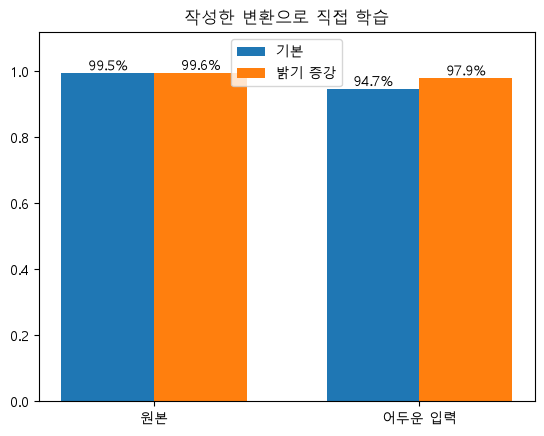

In [10]:
RETRAIN=True
STRENGTH=.6
EPOCHS=10
if RETRAIN:models={'기본':train_aug(0.),'밝기 증강':train_aug(STRENGTH)}
else:
    assert STRENGTH==.6 and EPOCHS==10,'설정을 바꿨으면 직접 학습하세요.'
    models={name:lab.load_model(ROOT/'models/comparison'/folder/'final.pt') for name,folder in [('기본','baseline'),('밝기 증강','augmented')]}
source_label='작성한 변환으로 직접 학습' if RETRAIN else '제공 모델 확인'
print('결과 출처:',source_label,'강도:',STRENGTH,'epochs:',EPOCHS)
results={};rows=[]
for factor in [1.,.4]:
    photos=np.stack([np.asarray(ImageEnhance.Brightness(Image.fromarray(p)).enhance(factor)) for p in data['val'].images])
    validation=lab.SignDataset(photos,data['val'].labels.copy())
    result={name:evaluate(model,validation) for name,model in models.items()};results[factor]=result
    rows.append([result[name]['accuracy'] for name in ['기본','밝기 증강']])
    print('평가 밝기',factor,'기본/증강 정답률',rows[-1],'변화(%p)',100*(rows[-1][1]-rows[-1][0]))
x=np.arange(2)
for i,name in enumerate(['기본','밝기 증강']):
    bars=plt.bar(x+(i-.5)*.35,[r[i] for r in rows],.35,label=name)
    plt.bar_label(bars,labels=[f'{r[i]:.1%}' for r in rows])
plt.xticks(x,['원본','어두운 입력']);plt.ylim(0,1.12);plt.legend();plt.title(source_label);plt.show()
result=results[.4]['밝기 증강']
truth=result['truth'];prediction=result['prediction'];scores=result['scores']

## ✏️ A05 · 클래스별 오류 보고서 구현

정답·예측·최대 클래스 점수에서 혼동행렬, 클래스별 정답률, 점수가 높은 오답 번호를 반환하세요.
행=정답, 열=예측. 표본이 없는 클래스의 정답률은 0으로 둡니다.
`wrong_ids`는 점수 내림차순 상위 최대 top_k개이며 동점은 원래 순서입니다.

### 사용할 수 있는 API
`np.zeros`, `np.diag`, `.sum(axis=1)`, `np.flatnonzero`, `np.argsort(..., kind="stable")`.
예: `np.argsort(-np.array([.2,.9,.5]), kind="stable")`는 `[1,2,0]`.
반환 사전 키: `confusion`, `class_accuracy`, `wrong_ids`.


In [13]:
# ===== 실습 A05 시작 =====

def classification_report(truth,prediction,scores,num_classes,top_k=4):
    matrix = np.zeros((num_classes, num_classes), dtype=int)
    for actual, guessed in zip(truth, prediction):matrix[actual, guessed]+=1
    counts=matrix.sum(axis=1)
    per_class=np.divide(np.diag(matrix), counts, out=np.zeros(num_classes, dtype=float), where=counts>0)
    wrong=np.flatnonzero(truth!=prediction)
    ranked=wrong[np.argsort(-scores[wrong], kind='stable')]
    return {'confusion':matrix, 'class_accuracy':per_class, 'wrong_ids':ranked[:top_k]}
    #raise NotImplementedError('A05: 오류 보고서 구현')

# ===== 실습 A05 끝 =====


**A05 검증** · 아래 셀이 통과한 뒤 실제 데이터에 적용합니다.


In [14]:
t=np.array([0,0,1,1]);p=np.array([0,1,2,1]);s=np.array([.5,.8,.9,.7])
r=classification_report(t,p,s,3,1)
assert np.array_equal(r['confusion'],[[1,1,0],[0,1,1],[0,0,0]])
assert np.allclose(r['class_accuracy'],[.5,.5,0]) and np.array_equal(r['wrong_ids'],[2]),'A05: 클래스별 집계·오답 정렬을 확인하세요.'
assert len(classification_report(t,t,s,3)['wrong_ids'])==0
assert np.array_equal(classification_report(t,p,np.ones(4),3)['wrong_ids'],[1,2])
print('A05 통과: 혼동·빈 클래스·오답 정렬·오답 없음')


A05 통과: 혼동·빈 클래스·오답 정렬·오답 없음


## 실제 오류 확인 · 제공 코드
방금 비교한 증강 모델의 어두운 입력 결과를 그대로 사용합니다.


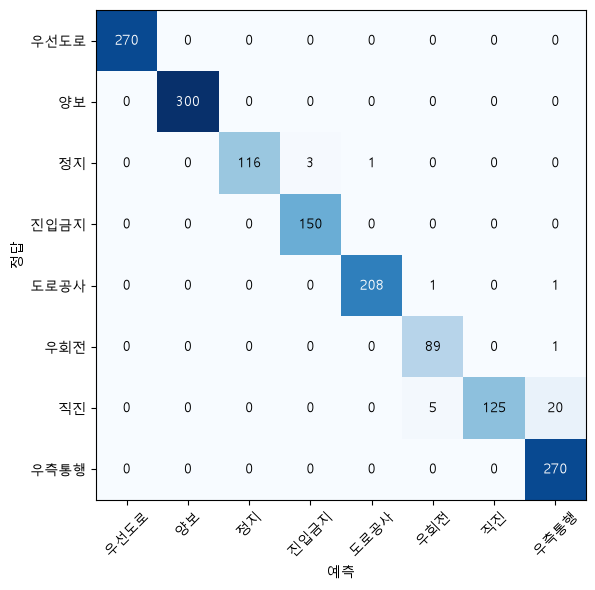

우선도로 100.0%
양보 100.0%
정지 96.7%
진입금지 100.0%
도로공사 99.0%
우회전 98.9%
직진 83.3%
우측통행 100.0%


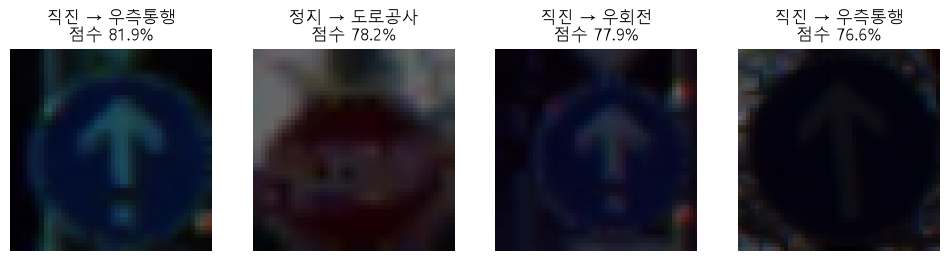

In [15]:
report=classification_report(truth,prediction,scores,8)
matrix=report['confusion'];fig,ax=plt.subplots(figsize=(7,6));ax.imshow(matrix,cmap='Blues')
for i in range(8):
    for j in range(8):ax.text(j,i,str(matrix[i,j]),ha='center',va='center',color='white' if matrix[i,j]>matrix.max()/2 else 'black')
ax.set_xticks(range(8),NAMES,rotation=45);ax.set_yticks(range(8),NAMES);ax.set_xlabel('예측');ax.set_ylabel('정답');plt.tight_layout();plt.show()
for name,rate in zip(NAMES,report['class_accuracy']):print(name,f'{rate:.1%}')
ids=report['wrong_ids']
if len(ids):
    fig,axes=plt.subplots(1,len(ids),figsize=(12,3),squeeze=False)
    for ax,i in zip(axes.flat,ids):ax.imshow(photos[i]);ax.axis('off');ax.set_title(f'{NAMES[truth[i]]} → {NAMES[prediction[i]]}\n점수 {scores[i]:.1%}')
    plt.show()
else:print('오답이 없습니다.')


## 검증으로 모델 선택·저장 · 제공 코드
원본·어두운 검증 사진의 평균 정답률로 모델을 선택하고, 직접 학습한 기본·증강 모델과 선택 기록을 함께 저장합니다. 03 카메라에서 바로 사용할 수 있습니다.
02는 01의 자유 설계와 분리해 같은 기본 구조에서 증강 효과만 비교합니다.

In [16]:
# 평가 조건은 검증 단계에서 고정합니다. 시험 결과로 다시 선택하지 않습니다.
validation_scores={name:float(np.mean([results[f][name]['accuracy'] for f in [1.,.4]])) for name in models}
selected_name=max(validation_scores,key=validation_scores.get)
selected_key='augmented' if selected_name=='밝기 증강' else 'baseline'
print('검증 평균 정답률(원본·밝기0.4 동일 비중):',validation_scores)
print('선택 모델:',selected_name)
# 카메라에서 원래 모델과 증강 모델을 비교할 수 있도록 두 모델을 보관합니다.
if RETRAIN:
    output_dir=ROOT/'outputs/student_model';output_dir.mkdir(parents=True,exist_ok=True)
    (output_dir/'selection.json').unlink(missing_ok=True)  # 이전 실험 선택 기록 초기화
    for name,key in [('기본','baseline'),('밝기 증강','augmented')]:
        with (output_dir/f'{key}.pt').open('wb') as file:
            torch.jit.save(torch.jit.trace(models[name].eval(),torch.zeros(1,3,48,48)),file)
        info=dict(source='02에서 직접 학습',model=name,architecture=str(models[name]),epochs=EPOCHS,strength=0. if key=='baseline' else STRENGTH)
        (output_dir/f'{key}.json').write_text(json.dumps(info,ensure_ascii=False,indent=2),encoding='utf-8')
    print('카메라 비교용 기본·증강 모델 저장 완료')
if RETRAIN:
    (output_dir/'selection.json').write_text(json.dumps(dict(key=selected_key,criterion='원본·밝기0.4 검증 정답률 평균',validation_scores=validation_scores),ensure_ascii=False,indent=2),encoding='utf-8')


검증 평균 정답률(원본·밝기0.4 동일 비중): {'기본': 0.9711538461538461, '밝기 증강': 0.9878205128205129}
선택 모델: 밝기 증강
카메라 비교용 기본·증강 모델 저장 완료


## 최종 시험 확인 · 선택 실행
실험을 마친 뒤 아래 `RUN_FINAL_TEST=True`로 바꾸어 실행하세요. 기본값에서는 시험 데이터를 평가하지 않습니다. 시험 결과로 모델을 다시 고르지 않습니다.

In [17]:
RUN_FINAL_TEST=False
if RUN_FINAL_TEST:
    test_rows=[]
    for factor in [1.,.4]:
        photos=np.stack([np.asarray(ImageEnhance.Brightness(Image.fromarray(p)).enhance(factor)) for p in data['test'].images])
        heldout=lab.SignDataset(photos,data['test'].labels.copy())
        test_result=evaluate(models[selected_name],heldout)
        test_rows.append(dict(brightness=factor,accuracy=test_result['accuracy'],n=len(heldout)))
    print('최종 시험 결과 / 모델 고정:',selected_name,test_rows)
else:
    print('시험 평가 대기: 실험을 마친 뒤 RUN_FINAL_TEST=True로 실행하세요.')


시험 평가 대기: 실험을 마친 뒤 RUN_FINAL_TEST=True로 실행하세요.
